In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
from torch import nn
  

import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

import JCBScope_utils
import JacobianScopes


# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Set input strings

In [3]:
system_prompt = ""

In [4]:
front_pad = 2
back_pad = 0

# string = "Tom loves Korean food. He grew up in the South and goes to Columbia. He is a conservative"
string = "Tom loves Korean food. He grew up in the South and goes to Columbia. Tom is a liberal"



# Define path of alpha (presence_ratio)
presence_ratios = np.linspace(0.01, 1, 100)

print(presence_ratios)

skip_delimiters = False
# skip_delimiters = True

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56
 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7
 0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84
 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98
 0.99 1.  ]


### Load models

In [6]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "meta-llama/Llama-2-7b-chat-hf"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

In [7]:
model.device

device(type='cpu')

### Check if the input and output embeddings are the same

In [8]:
lm_head = JCBScope_utils.get_lm_head(model)
input_embed = JCBScope_utils.get_input_embeddings(model)


is_weight_tied = input_embed.weight is lm_head.weight
print(f"Are input and output layer weights tied? {is_weight_tied}")

Are input and output layer weights tied? True


In [9]:
sys_prompt_tokens = tokenizer(system_prompt, add_special_tokens=False)["input_ids"]

sys_token_len = len(sys_prompt_tokens)

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Add system prompt
input_ids_list += sys_prompt_tokens
# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(model.device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,  25763,  16180,  16526,   3691,     13,   1283,  14264,
            709,    304,    279,   4987,    323,   5900,    311,  19326,     13,
           8529,    374,    264,  18250]])
vocab size: 128256
0 128000 '<|begin_of_text|>'
1 128000 '<|begin_of_text|>'
2 25763 'Tom'
3 16180 ' loves'
4 16526 ' Korean'
5 3691 ' food'
6 13 '.'
7 1283 ' He'
8 14264 ' grew'
9 709 ' up'
10 304 ' in'
11 279 ' the'
12 4987 ' South'
13 323 ' and'
14 5900 ' goes'
15 311 ' to'
16 19326 ' Columbia'
17 13 '.'
18 8529 ' Tom'
19 374 ' is'
20 264 ' a'
21 18250 ' liberal'
['', '', 'Tom', ' loves', ' Korean', ' food', '.', ' He', ' grew', ' up', ' in', ' the', ' South', ' and', ' goes', ' to', ' Columbia', '.', ' Tom', ' is', ' a', ' liberal']


In [10]:
### Set which tokens to perform gradients on
### Skip comma delimiters  

if skip_delimiters:
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),2)]
else:
    ### all positions
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),1)]
    # grad_idx = [idx for idx in range(0,len(decoded_tokens),1)]

print(grad_idx)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


### Customize forward function

In [11]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [19]:
hidden_norm_as_loss = False
unnormalized_logits = True
loss_position = grad_idx[-1] - 1

scores, grads_per_step, input_embeds_per_step = JacobianScopes.semantic_scope_scores(
    forward_pass, residual, loss_position,
    path_integral=True,
    presence_ratios=presence_ratios,
    grad_idx=grad_idx,
    return_grads_per_step=True,
)
logits_per_step = []  # not returned by module; leave empty for compatibility
print(f"Path-integrated semantic scope computed over {len(presence_ratios)} steps.")



Path-integrated semantic scope computed over 100 steps.


In [26]:
input_embed_at_x_f = input_embeds_per_step[-1][0, grad_idx, :]

### Visualize

In [27]:
# steps_to_plot = list(range(0, len(presence_ratios),5))
steps_to_plot = [0,1,7,39,79,99]

/data/tmp/ipykernel_2167129/2750843339.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=0)  # reduce vertical padding between subplots


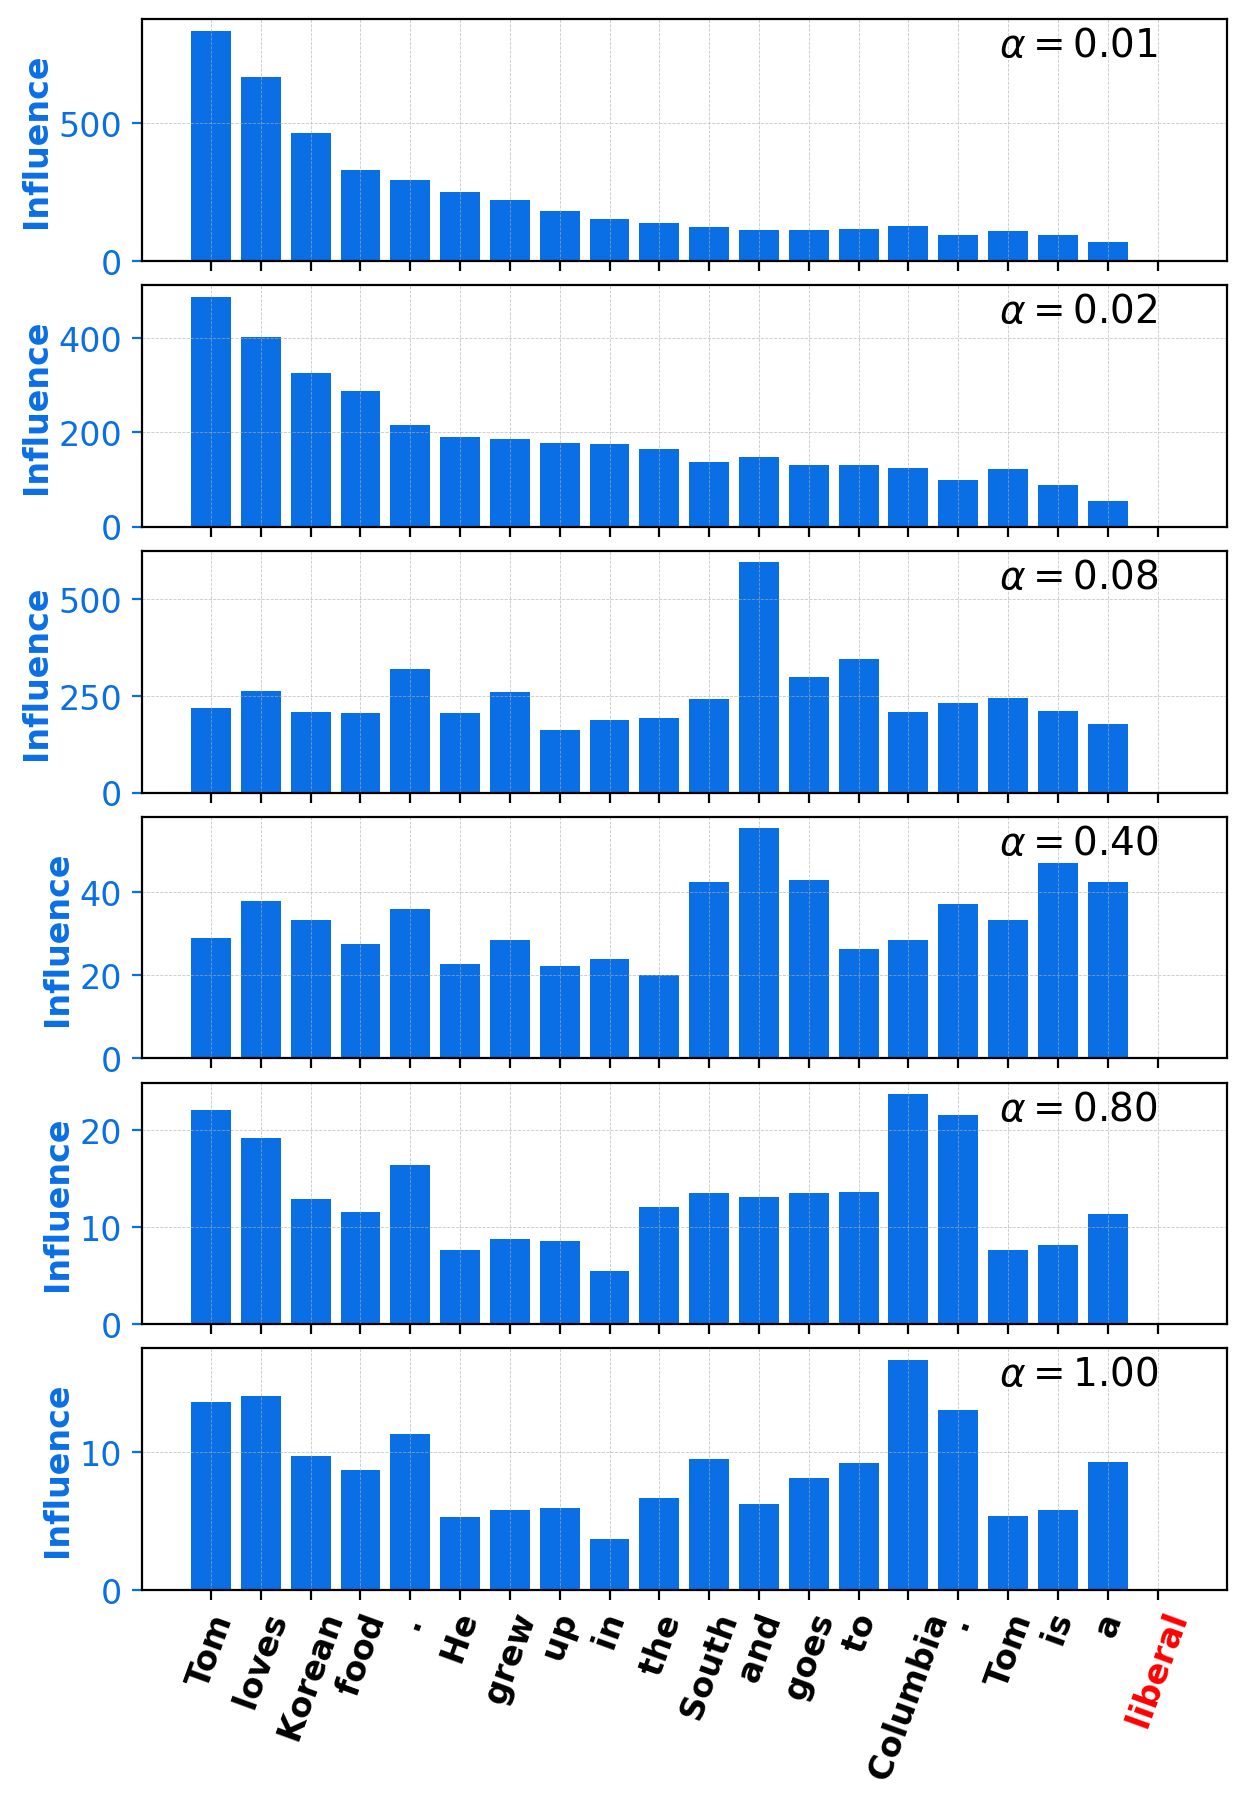

In [28]:
ax1_color = np.array([10, 110, 230])/256
label_font_size = 12

def plotter(grad, ax, alpha_label):
    hardset_target_grad = 1

    optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]
    tick_label_text = optimized_tokens.copy()

    if len(grad.shape) == 2:
        grad_magnitude = grad.norm(dim=-1).squeeze()  # shape [seq_len]
    else:
        grad_magnitude = grad

    bar_idx = grad_idx.index(loss_position+1)

    bars = ax.bar(
        range(grad_magnitude.shape[0]), 
        grad_magnitude, 
        tick_label=tick_label_text, 
        color=ax1_color,
    )
    

    if hardset_target_grad:
        bars[bar_idx].set_color('black')

    # Only set xticks, labels, and highlight on the bottom axis later.
    ax.set_ylabel('Influence', labelpad=2, color=ax1_color, fontsize=label_font_size, fontweight='bold')
    ax.tick_params(axis='y', colors=ax1_color, labelsize=label_font_size)

    ax.xaxis.grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
    ax.yaxis.grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
    ax.grid(True, axis='y')

    # Remove default title, instead annotate alpha in top right corner
    ax.annotate(alpha_label, xy=(0.79, 0.97), xycoords='axes fraction',
                ha='left', va='top', fontsize=14, fontweight='bold')

# Now prepare shared-x plots:
import matplotlib.pyplot as plt

optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]
tick_label_text = optimized_tokens.copy()

num_plots = len(steps_to_plot) 

# Decrease spacing between axes by adjusting hspace in gridspec_kw
fig, axes = plt.subplots(
    num_plots, 1, 
    figsize=(7, num_plots * 1.7), 
    sharex=True, 
    dpi=200,
    gridspec_kw={'hspace': 0.1}  # Make the vertical distance smaller (default ~0.2)
)
if num_plots == 1:
    axes = [axes]

# Loop over every other step by skipping alternate indices
# We will plot 1, 3, 5, ... instead of every index from 1 to len(presence_ratios)-1


for i, step_idx in enumerate(steps_to_plot):
    grad = grads_per_step[step_idx]
    alpha_val = presence_ratios[step_idx]
    alpha_label = rf'$\alpha={alpha_val:.2f}$'
    plotter(grad, axes[i], alpha_label)

# After all plots, format bottom axis:
ax = axes[len(steps_to_plot)-1]
plt.sca(ax)
plt.xticks(rotation=70, fontsize=12, fontweight='bold')
bar_idx = grad_idx.index(loss_position+1)
xtick_labels = ax.get_xticklabels()
xtick_labels[bar_idx].set_color('red')

plt.tight_layout(h_pad=0)  # reduce vertical padding between subplots
plt.show()

### Integrate over the linear path

In [43]:
from typing import Any

IG_slice = slice(0,len(presence_ratios))


alphas = torch.tensor(presence_ratios[IG_slice])[:, None, None]    

# Path_integrated_grad = torch.mean(
#     torch.stack(grads_per_step[IG_slice]) * alphas, 
#     axis=0) * (
#     input_embeds_per_step[IG_slice.stop-1][0, grad_idx, :] -
#     input_embeds_per_step[IG_slice.start][0, grad_idx, :])
    
Path_integrated_grad = torch.mean(
    torch.stack(grads_per_step[IG_slice]), 
    axis=0) * (
    input_embeds_per_step[IG_slice.stop-1][0, grad_idx, :] -
    input_embeds_per_step[IG_slice.start][0, grad_idx, :])
    

Path Integration from 0.01 to 1.0


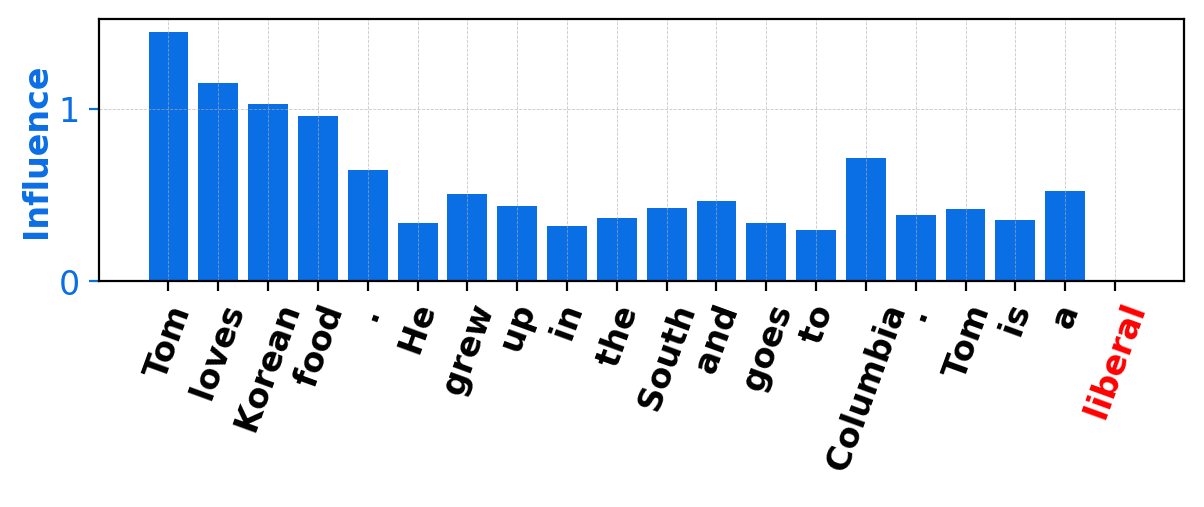

In [44]:
fig, ax = plt.subplots(figsize=(7, 1.7), dpi=200)
grad = Path_integrated_grad.norm(dim=-1).squeeze()   
full_title = f'Path Integration from {presence_ratios[IG_slice.start]} to {presence_ratios[IG_slice.stop-1]}'
# full_title = rf'IG with $\alpha=0$ to ${presence_ratios[IG_slice.stop-1]}$'
print(full_title)
plotter(grad,ax, '')
# After all plots, format bottom axis:
plt.sca(ax)
plt.xticks(rotation=70, fontsize=12, fontweight='bold')
bar_idx = grad_idx.index(loss_position+1)
xtick_labels = ax.get_xticklabels()
xtick_labels[bar_idx].set_color('red')


Integrand evaluated at 1.0


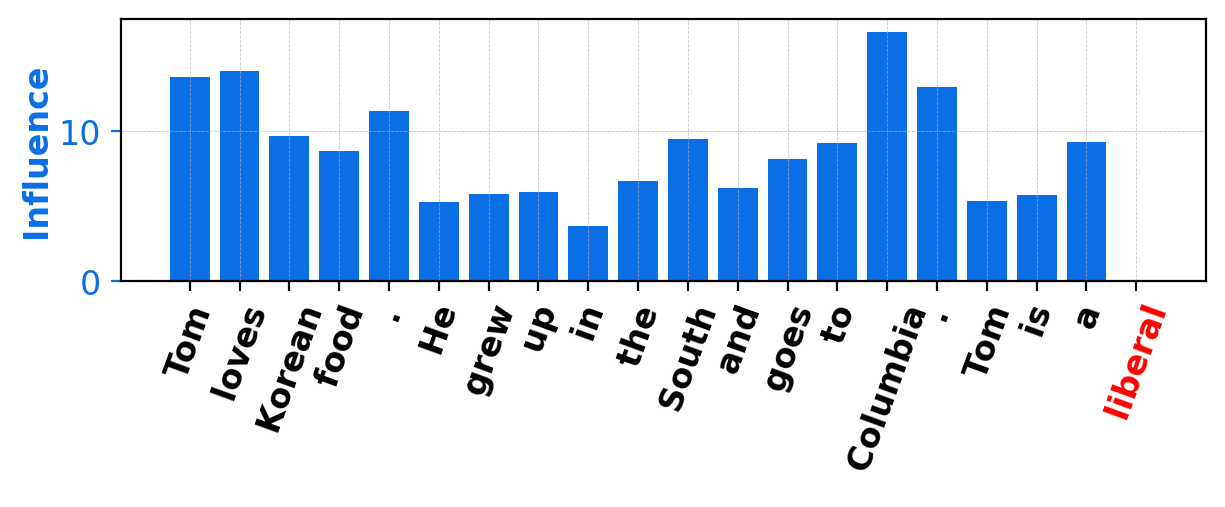

In [31]:
fig, ax = plt.subplots(figsize=(7, 1.7), dpi=200)
grad = grads_per_step[-1]
full_title = f'Integrand evaluated at {presence_ratios[-1]}'
# full_title = rf'IG with $\alpha=0$ to ${presence_ratios[IG_slice.stop-1]}$'
print(full_title)
plotter(grad,ax, '')
# After all plots, format bottom axis:
plt.sca(ax)
plt.xticks(rotation=70, fontsize=12, fontweight='bold')
bar_idx = grad_idx.index(loss_position+1)
xtick_labels = ax.get_xticklabels()
xtick_labels[bar_idx].set_color('red')
